## Initial condition - First Excited State
- Similiar to the previous notebook, I will be training this model with initial condition as the first excited state alone
- Everything else will remain the same

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
hbar = 1
m = 1
omega = 1

x_min = -np.pi
x_max = np.pi
t_min = 0
t_max = 2 * np.pi

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS backend for Apple GPU acceleration!")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using cuda")
else:
    device = torch.device("cpu")
    print("Using CPU instead.")

Using cuda


In [4]:
class PINN(nn.Module):
	def __init__(self, layers):
		super(PINN, self).__init__()
		self.hidden_layers = nn.ModuleList()
		for units in layers[1:-1]:
			self.hidden_layers.append(nn.Linear(in_features=layers[0], out_features=units))
			layers[0] = units

		self.output_layer = nn.Linear(layers[-2], layers[-1])

	def forward(self, inputs):
		x, t = inputs
		X = torch.stack((x, t), dim=1)

		for layer in self.hidden_layers:
			X = layer(X)
			X = torch.tanh(X)

		output = self.output_layer(X)
		psi_real = output[:, 0]
		psi_img = output[:, 1]

		return psi_real, psi_img

In [5]:
layers = [2, 512, 512, 512, 512, 512, 512, 2]

In [6]:
n_collocation = 3140
n_initial = 314
n_boundary = 200

In [7]:
def generator():
	x_collocation = np.random.uniform(x_min, x_max, n_collocation)
	t_collocation = np.random.uniform(t_min, t_max, n_collocation)

	x_initial = np.random.uniform(x_min, x_max, n_initial)
	t_initial = np.full(n_initial, t_min)

	x_boundary = np.concatenate([np.full(n_boundary // 2, x_min), np.full(n_boundary // 2, x_max)])
	t_boundary = np.random.uniform(t_min, t_max, n_boundary)

	x_collocation_torch = torch.from_numpy(x_collocation).float().to(device)
	t_collocation_torch = torch.from_numpy(t_collocation).float().to(device)

	x_initial_torch  = torch.from_numpy(x_initial).float().to(device)
	t_initial_torch  = torch.from_numpy(t_initial).float().to(device)

	x_boundary_torch = torch.from_numpy(x_boundary).float().to(device)
	t_boundary_torch = torch.from_numpy(t_boundary).float().to(device)

	return x_collocation_torch, t_collocation_torch, x_initial_torch, t_initial_torch, x_boundary_torch, t_boundary_torch

In [8]:
model = PINN(layers)
model.to(device)

PINN(
  (hidden_layers): ModuleList(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1-5): 5 x Linear(in_features=512, out_features=512, bias=True)
  )
  (output_layer): Linear(in_features=512, out_features=2, bias=True)
)

In [9]:
optimizer = torch.optim.Adam(
  model.parameters(),
  lr=0.001,
  betas=(0.09, 0.999)
)

a0 = 0.001
decay_rate = 0.9
steps = 2000

def exp_decay(step):
  return decay_rate ** (step / steps)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=exp_decay)

In [10]:
def loss_function(x_collocation_torch, t_collocation_torch, x_initial_torch, t_initial_torch, x_boundary_torch, t_boundary_torch):
	#pde loss
	x_collocation_torch = x_collocation_torch.clone().requires_grad_(True)
	t_collocation_torch = t_collocation_torch.clone().requires_grad_(True)

	u, v = model((x_collocation_torch, t_collocation_torch))

	du_dt = torch.autograd.grad(u, t_collocation_torch, grad_outputs=torch.ones_like(u), create_graph=True)[0]
	du_dx = torch.autograd.grad(u, x_collocation_torch, grad_outputs=torch.ones_like(u), create_graph=True)[0]
	d2u_dx2 = torch.autograd.grad(du_dx, x_collocation_torch, grad_outputs=torch.ones_like(du_dx), create_graph=True)[0]

	dv_dt = torch.autograd.grad(v, t_collocation_torch, grad_outputs=torch.ones_like(v), create_graph=True)[0]
	dv_dx = torch.autograd.grad(v, x_collocation_torch, grad_outputs=torch.ones_like(v), create_graph=True)[0]
	d2v_dx2 = torch.autograd.grad(dv_dx, x_collocation_torch, grad_outputs=torch.ones_like(dv_dx), create_graph=True)[0]

	real = -dv_dt + 0.5 * d2u_dx2 - 0.5 * (x_collocation_torch ** 2) * u
	img = du_dt + 0.5 * d2v_dx2 - 0.5 * (x_collocation_torch ** 2) * v

	physics_loss = torch.mean(real ** 2 + img ** 2)




	#initial condition loss
	u_i, v_i = model((x_initial_torch, t_initial_torch))

	psi_0 = ((1 / np.pi) ** 0.25) * torch.exp(-0.5 * (x_initial_torch ** 2))
	psi_1 = psi_0 * np.sqrt(2) * x_initial_torch
	psi_initial_actual = psi_1

	initial_condition_loss = torch.mean((u_i - psi_initial_actual) ** 2) + torch.mean((v_i - 0) ** 2)




	#boundary condition loss
	u_b, v_b = model((x_boundary_torch, t_boundary_torch))
	boundary_condition_loss = torch.mean(u_b ** 2) + torch.mean(v_b ** 2)

	return physics_loss, initial_condition_loss, boundary_condition_loss

In [11]:
epochs = 150000
history = []

for epoch in range(1, epochs+1):
  optimizer.zero_grad()

  physics_loss, initial_condition_loss, boundary_condition_loss = loss_function(*generator())
  total_loss = 10 * physics_loss + initial_condition_loss + boundary_condition_loss

  total_loss.backward()
  optimizer.step()
  scheduler.step()

  history.append({"total_loss": total_loss.item() ,"physics_loss": physics_loss.item(), "initial_condition_loss": initial_condition_loss.item(), "boundary_condition_loss": boundary_condition_loss.item()})

  if epoch % 1500 == 0:
    print(f"Epoch {epoch}/{epochs}")
    print(f"Total loss: {total_loss.item():.4e}")
    print(f"Physics loss: {physics_loss.item():.4e}")
    print(f"Initial condition loss: {initial_condition_loss.item():.4e}")
    print(f"Boundary condition loss: {boundary_condition_loss.item():.4e}")
    print("-" * 50)
    

Epoch 1500/150000
Total loss: 1.6997e-01
Physics loss: 2.3329e-03
Initial condition loss: 1.4607e-01
Boundary condition loss: 5.6846e-04
--------------------------------------------------
Epoch 3000/150000
Total loss: 1.8345e+00
Physics loss: 1.6246e-01
Initial condition loss: 1.7930e-01
Boundary condition loss: 3.0549e-02
--------------------------------------------------
Epoch 4500/150000
Total loss: 2.6678e-01
Physics loss: 1.1477e-02
Initial condition loss: 1.4971e-01
Boundary condition loss: 2.2970e-03
--------------------------------------------------
Epoch 6000/150000
Total loss: 1.5412e-01
Physics loss: 7.5690e-04
Initial condition loss: 1.4636e-01
Boundary condition loss: 1.9087e-04
--------------------------------------------------
Epoch 7500/150000
Total loss: 2.2670e+00
Physics loss: 2.0494e-01
Initial condition loss: 1.7652e-01
Boundary condition loss: 4.1124e-02
--------------------------------------------------
Epoch 9000/150000
Total loss: 1.0227e+00
Physics loss: 8.341

In [12]:
total_loss_history = [record['total_loss'] for record in history]
physics_loss_history = [record['physics_loss'] for record in history]
initial_condition_loss_history = [record['initial_condition_loss'] for record in history]
boundary_condition_loss_history = [record['boundary_condition_loss'] for record in history]

epochs_range = range(1, epochs + 1)

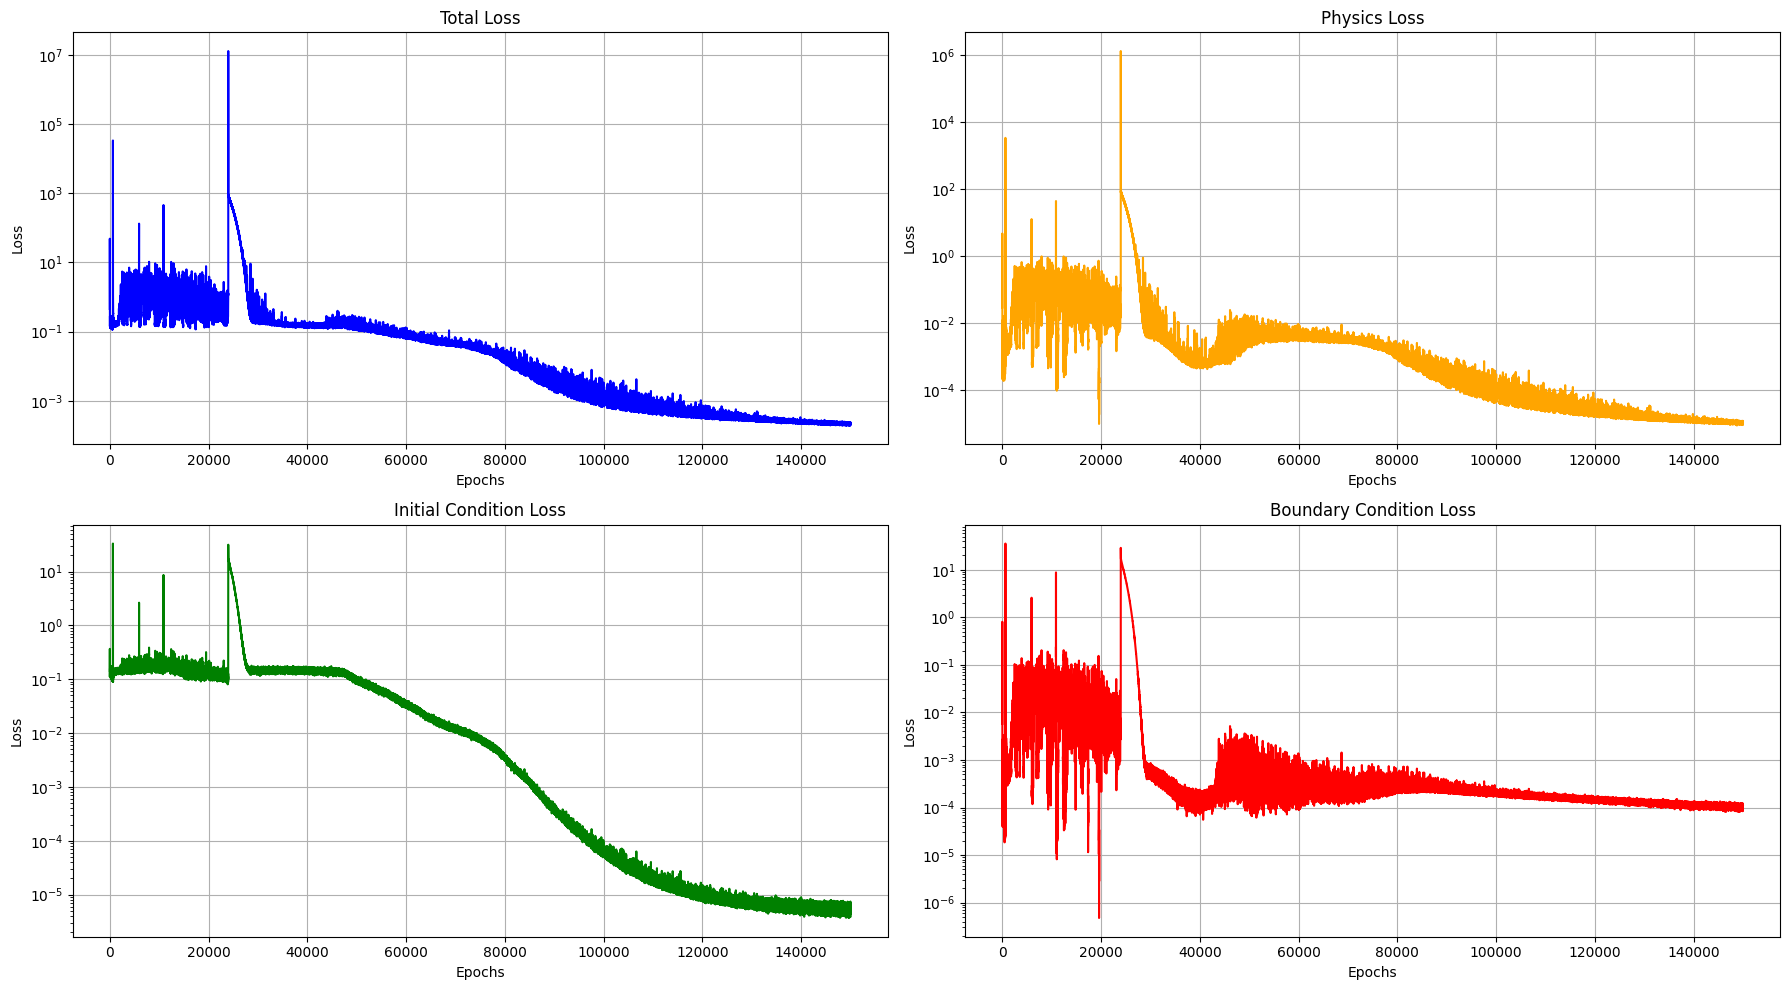

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))

# Total Loss
axs[0, 0].plot(epochs_range, total_loss_history, color='blue')
axs[0, 0].set_title('Total Loss')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)
axs[0, 0].set_yscale("log")

# Physics Loss
axs[0, 1].plot(epochs_range, physics_loss_history, color='orange')
axs[0, 1].set_title('Physics Loss')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].grid(True)
axs[0, 1].set_yscale("log")

# Initial Condition Loss
axs[1, 0].plot(epochs_range, initial_condition_loss_history, color='green')
axs[1, 0].set_title('Initial Condition Loss')
axs[1, 0].set_xlabel('Epochs')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].grid(True)
axs[1, 0].set_yscale("log")

# Boundary Condition Loss
axs[1, 1].plot(epochs_range, boundary_condition_loss_history, color='red')
axs[1, 1].set_title('Boundary Condition Loss')
axs[1, 1].set_xlabel('Epochs')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].grid(True)
axs[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()

In [14]:
Nx = 628
Nt = 628

x_values = np.linspace(x_min, x_max, Nx)
t_values = np.linspace(t_min, t_max, Nt)

In [15]:
def analytical(x, t):
    A = ((1 / np.pi) ** 0.25) * np.exp(-(x ** 2) / 2)
    B = np.exp(-1j * 1.5 * t) * np.sqrt(2) * x
    return A * B

In [16]:
psi_real_analytical = np.zeros((Nx, Nt), dtype=np.float64)
psi_img_analytical = np.zeros((Nx, Nt), dtype=np.float64)

for i, x in enumerate(x_values):
    for j, t in enumerate(t_values):
        psi_x_t = analytical(x, t)

        psi_real_analytical[i, j] = np.real(psi_x_t)
        psi_img_analytical[i, j] = np.imag(psi_x_t)

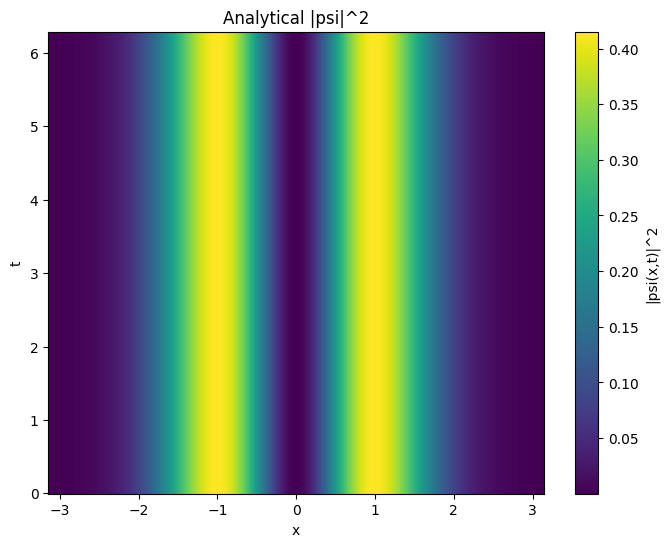

In [17]:
plt.figure(figsize=(8, 6))
psi_sq_analytical = psi_real_analytical ** 2 + psi_img_analytical ** 2

plt.pcolormesh(x_values, t_values, psi_sq_analytical.transpose(), shading="auto")
plt.colorbar(label='|psi(x,t)|^2')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Analytical |psi|^2')
plt.show()

In [18]:
x_values_torch = torch.from_numpy(x_values).float().to(device)
t_values_torch = torch.from_numpy(t_values).float().to(device)

x_grid, t_grid = torch.meshgrid(x_values_torch, t_values_torch, indexing="ij")

x_flat = torch.reshape(x_grid, [-1])
t_flat = torch.reshape(t_grid, [-1])

psi_real_pinn, psi_img_pinn = model((x_flat, t_flat))

psi_real_pinn = torch.reshape(psi_real_pinn, (Nx, Nt))
psi_img_pinn = torch.reshape(psi_img_pinn, (Nx, Nt))

psi_real_pinn = psi_real_pinn.detach().cpu().numpy()
psi_img_pinn = psi_img_pinn.detach().cpu().numpy()

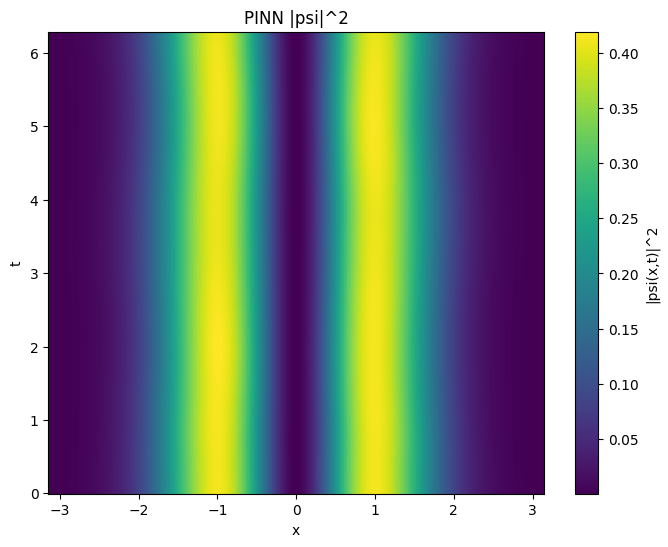

In [19]:
plt.figure(figsize=(8, 6))
psi_sq = psi_real_pinn ** 2 + psi_img_pinn ** 2

plt.pcolormesh(x_values, t_values, psi_sq.transpose(), shading="auto")
plt.colorbar(label='|psi(x,t)|^2')
plt.xlabel('x')
plt.ylabel('t')
plt.title('PINN |psi|^2')
plt.show()

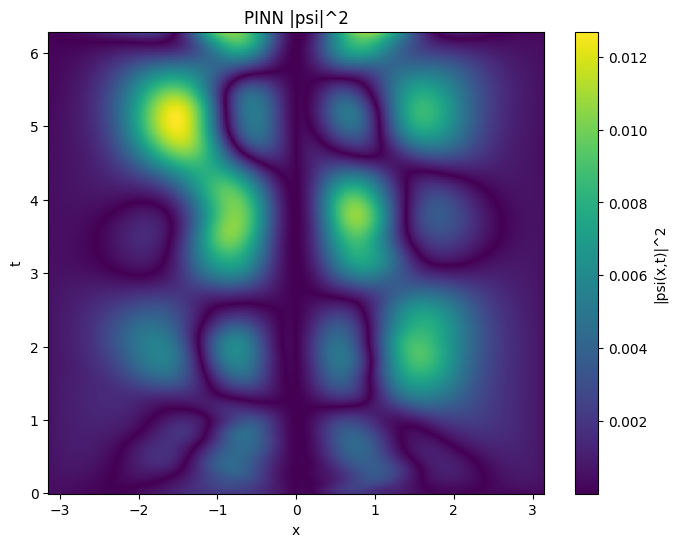

In [20]:
plt.figure(figsize=(8, 6))
psi_sq_diff = np.abs(psi_sq - psi_sq_analytical)

plt.pcolormesh(x_values, t_values, psi_sq_diff.transpose(), shading="auto")
plt.colorbar(label='|psi(x,t)|^2')
plt.xlabel('x')
plt.ylabel('t')
plt.title('PINN |psi|^2')
plt.show()

In [21]:
psi_analytical_mag = psi_real_analytical ** 2 + psi_img_analytical ** 2
psi_pinn_mag = psi_real_pinn ** 2 + psi_img_pinn ** 2

mse = (np.square(psi_analytical_mag - psi_pinn_mag)).mean()

print(f"Mean Squared Error: {mse:.3e}")

Mean Squared Error: 1.311e-05


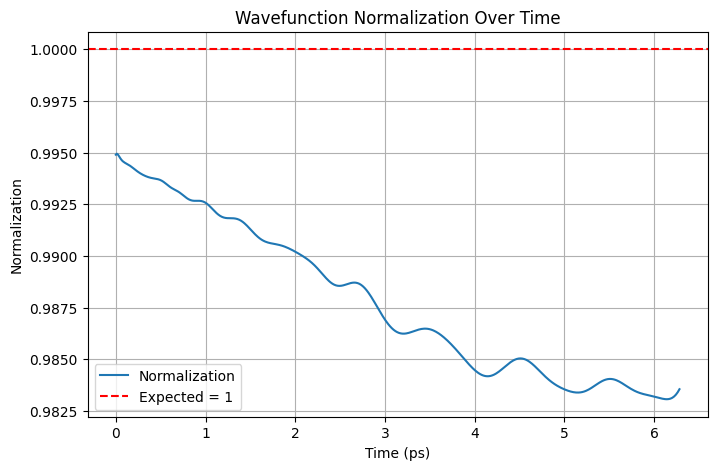

In [22]:
from scipy.integrate import simpson

norms = []

for i in range(628):
	psi_sq = psi_real_pinn[:, i] ** 2 + psi_img_pinn[:, i] ** 2
	normalization = simpson(psi_sq, x=x_values)
	norms.append(normalization)

plt.figure(figsize=(8,5))
plt.plot(t_values, norms, '-', label='Normalization')
plt.axhline(1.0, color='red', linestyle='--', label='Expected = 1')
plt.xlabel('Time (ps)')
plt.ylabel('Normalization')
plt.title('Wavefunction Normalization Over Time')
plt.legend()
plt.grid(True)
plt.show()